# Gender Classification Using a Simple CNN

This notebook teaches a complete image-classification workflow using the labeled images already stored in `data/`. The CNN learns the dataset-provided labels; it does not determine a person's gender identity.

OpenCV YuNet answers **where a face is**. The CNN answers **which dataset label the cropped face resembles**.

The first experiment uses a reproducible subset so training stays practical in a Codespace. The Streamlit app is the recommended camera and image-upload demonstration.

## 1. Import Libraries

These are the only libraries needed for the CNN, image handling, plots, and evaluation.

In [2]:
import random
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print(f"TensorFlow version: {tf.__version__}")

I0000 00:00:1788869321.764647   34311 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788869323.565438   34311 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788869328.871579   34311 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow version: 2.21.0


## 2. Project Paths and Configuration

The original dataset is never copied or modified. Only file paths are sampled.

In [3]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
TRAIN_DIR = PROJECT_ROOT / 'data' / 'Training'
VALIDATION_DIR = PROJECT_ROOT / 'data' / 'Validation'
MODEL_PATH = PROJECT_ROOT / 'models' / 'gender_cnn.keras'
FACE_DETECTOR_PATH = PROJECT_ROOT / 'models' / 'face_detection_yunet_2023mar.onnx'
IMAGE_PATH = PROJECT_ROOT / 'sample_images' / 'test.jpg'
VIDEO_PATH = PROJECT_ROOT / 'sample_videos' / 'test_video.mp4'
OUTPUT_VIDEO_PATH = PROJECT_ROOT / 'sample_videos' / 'gender_prediction_output.mp4'

IMG_SIZE = 128
BATCH_SIZE = 32
MAX_TRAIN_IMAGES_PER_CLASS = 5000
MAX_VALIDATION_IMAGES_PER_CLASS = 1000
EPOCHS = 10
RANDOM_SEED = 42
FACE_SCORE_THRESHOLD = 0.85

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')
print(f'Training folder: {TRAIN_DIR}')
print(f'Validation folder: {VALIDATION_DIR}')

Project root: /workspaces/ImageClassficiationProject
Training folder: /workspaces/ImageClassficiationProject/data/Training
Validation folder: /workspaces/ImageClassficiationProject/data/Validation


## 3. Check the Dataset

Before training, confirm that both label folders exist in both splits. The labels are inferred from folder names, so their order must be read rather than guessed.

In [5]:
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.gif'}


def image_paths_by_class(split_dir):
    split_dir = Path(split_dir)
    if not split_dir.is_dir():
        raise FileNotFoundError(f'Dataset folder not found: {split_dir}')
    class_dirs = sorted(path for path in split_dir.iterdir() if path.is_dir())
    if len(class_dirs) != 2:
        raise ValueError(f'Expected exactly two class folders in {split_dir}, found {len(class_dirs)}')
    image_paths = {}
    for class_dir in class_dirs:
        paths = sorted(path for path in class_dir.rglob('*') if path.suffix.lower() in IMAGE_EXTENSIONS)
        image_paths[class_dir.name] = paths
    return image_paths


train_available = image_paths_by_class(TRAIN_DIR)
validation_available = image_paths_by_class(VALIDATION_DIR)
class_names = sorted(train_available)

if class_names != sorted(validation_available):
    raise ValueError('Training and validation must contain the same class folders.')

print('Class names:', class_names)
for split_name, split_data in [('Training', train_available), ('Validation', validation_available)]:
    print(f'\n{split_name}:')
    for class_name in class_names:
        print(f'  {class_name}: {len(split_data[class_name]):,} available images')

Class names: ['female', 'male']

Training:
  female: 23,243 available images
  male: 23,766 available images

Validation:
  female: 5,841 available images
  male: 4,744 available images


## 4. Choose a Reproducible Subset

A fixed seed gives the same file selection each time. This reduces training time and memory use while leaving the full dataset untouched.

In [6]:
def choose_subset(paths_by_class, maximum_per_class, seed=RANDOM_SEED):
    generator = random.Random(seed)
    selected = []
    for class_name in sorted(paths_by_class):
        paths = list(paths_by_class[class_name])
        generator.shuffle(paths)
        selected.extend((path, class_name) for path in paths[:maximum_per_class])
    generator.shuffle(selected)
    return selected


train_selected = choose_subset(train_available, MAX_TRAIN_IMAGES_PER_CLASS)
validation_selected = choose_subset(validation_available, MAX_VALIDATION_IMAGES_PER_CLASS)

for split_name, selected, available in [
    ('Training', train_selected, train_available),
    ('Validation', validation_selected, validation_available),
]:
    print(f'\n{split_name}:')
    for class_name in class_names:
        available_count = len(available[class_name])
        selected_count = sum(label == class_name for _, label in selected)
        print(f'  {class_name}: {available_count:,} available, {selected_count:,} selected')


Training:
  female: 23,243 available, 5,000 selected
  male: 23,766 available, 5,000 selected

Validation:
  female: 5,841 available, 1,000 selected
  male: 4,744 available, 1,000 selected


## 5. Load the Selected Images

This loader reads only the sampled paths and keeps the existing Training/Validation split. A failed image read is reported and skipped.

In [7]:
class_to_index = {class_name: index for index, class_name in enumerate(class_names)}


def load_selected_images(selected_paths):
    images, labels, unreadable = [], [], []
    for image_path, class_name in selected_paths:
        image = cv2.imread(str(image_path))
        if image is None:
            unreadable.append(image_path)
            continue
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
        images.append(image)
        labels.append(class_to_index[class_name])
    if unreadable:
        print(f'Skipped {len(unreadable)} unreadable image(s).')
    return np.asarray(images, dtype=np.uint8), np.asarray(labels, dtype=np.int32)


train_images, train_labels = load_selected_images(train_selected)
validation_images, validation_labels = load_selected_images(validation_selected)
print('Training array:', train_images.shape, train_labels.shape)
print('Validation array:', validation_images.shape, validation_labels.shape)

Training array: (10000, 128, 128, 3) (10000,)
Validation array: (2000, 128, 128, 3) (2000,)


## 6. Explore the Selected Images

The sample grid makes the labels and image quality visible before training. The counts above also show whether the subset is reasonably balanced.

Selected training counts: [5000 5000]
Selected validation counts: [1000 1000]


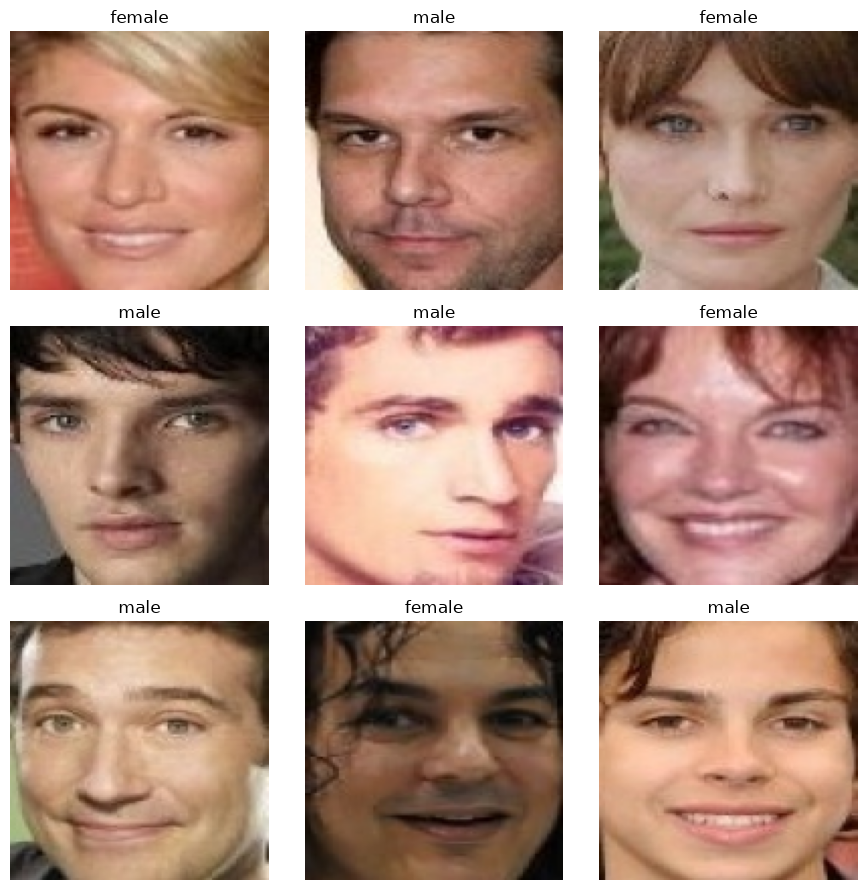

In [8]:
print('Selected training counts:', np.bincount(train_labels, minlength=len(class_names)))
print('Selected validation counts:', np.bincount(validation_labels, minlength=len(class_names)))

sample_count = min(9, len(train_images))
figure, axes = plt.subplots(3, 3, figsize=(9, 9))
for axis, image, label in zip(axes.flat, train_images[:sample_count], train_labels[:sample_count]):
    axis.imshow(image)
    axis.set_title(class_names[label])
    axis.axis('off')
for axis in axes.flat[sample_count:]:
    axis.axis('off')
plt.tight_layout()
plt.show()

## 7. Preprocessing and Data Augmentation

The model receives RGB images resized to `128 x 128`. `Rescaling` changes pixel values from `0-255` to `0-1`. Augmentation is used only for training, so validation remains an honest check.

In [9]:
train_dataset = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
validation_dataset = tf.data.Dataset.from_tensor_slices((validation_images, validation_labels))

augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
], name='simple_augmentation')

train_dataset = train_dataset.shuffle(len(train_images), seed=RANDOM_SEED).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
validation_dataset = validation_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
print('Datasets are ready.')

E0000 00:00:1788865627.288303    7340 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
W0000 00:00:1788865627.289355    7340 cpu_allocator_impl.cc:82] Allocation of 491520000 exceeds 10% of free system memory.
W0000 00:00:1788865627.887387    7340 cpu_allocator_impl.cc:82] Allocation of 98304000 exceeds 10% of free system memory.


Datasets are ready.


## 8. Build the CNN

Convolution layers find visual patterns, pooling reduces feature-map size, flatten converts features to a vector, dense makes the decision, and dropout helps reduce overfitting.

In [10]:
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Conv2D, Dense, Dropout, Flatten, MaxPooling2D, Rescaling

inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = augmentation(inputs)
x = Rescaling(1.0 / 255)(x)
x = Conv2D(32, kernel_size=(3, 3), activation='relu')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Conv2D(64, kernel_size=(3, 3), activation='relu')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Conv2D(128, kernel_size=(3, 3), activation='relu')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Conv2D(256, kernel_size=(3, 3), activation='relu')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
outputs = Dense(1, activation='sigmoid', name='gender_out')(x)

model = Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_augmentation             │ (None, 128, 128, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gender_out (Dense)              │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,748,225 (10.48 MB)

 Trainable params: 2,748,225 (10.48 MB)

 Non-trainable params: 0 (0.00 B)

## 9. Compile the Model

Adam updates the weights, binary crossentropy measures two-class mistakes, and accuracy reports the percentage of correct predictions.

In [11]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'],
)
print('Model compiled for two classes:', class_names)

Model compiled for two classes: ['female', 'male']


## 10. Train the Model

Early stopping ends training when validation loss stops improving and restores the best weights.

In [12]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping],
)

Epoch 1/10


/workspaces/ImageClassficiationProject/.venv-tf/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
W0000 00:00:1788865669.478195    7340 cpu_allocator_impl.cc:82] Allocation of 491520000 exceeds 10% of free system memory.
W0000 00:00:1788865672.038399    9640 cpu_allocator_impl.cc:82] Allocation of 65028096 exceeds 10% of free system memory.
W0000 00:00:1788865672.453153    9640 cpu_allocator_impl.cc:82] Allocation of 16257024 exceeds 10% of free system memory.


313/313 ━━━━━━━━━━━━━━━━━━━━ 241s 761ms/step - accuracy: 0.6726 - loss: 0.5834 - val_accuracy: 0.8285 - val_loss: 0.4045
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 235s 751ms/step - accuracy: 0.8274 - loss: 0.4087 - val_accuracy: 0.8855 - val_loss: 0.3119
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 233s 744ms/step - accuracy: 0.8581 - loss: 0.3472 - val_accuracy: 0.8825 - val_loss: 0.2882
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 264s 750ms/step - accuracy: 0.8856 - loss: 0.2809 - val_accuracy: 0.9330 - val_loss: 0.1817
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 274s 789ms/step - accuracy: 0.9106 - loss: 0.2397 - val_accuracy: 0.9320 - val_loss: 0.1847
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 237s 758ms/step - accuracy: 0.9183 - loss: 0.2154 - val_accuracy: 0.9320 - val_loss: 0.1772
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 245s 783ms/step - accuracy: 0.9236 - loss: 0.1931 - val_accuracy: 0.9255 - val_loss: 0.2064
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 257s 768ms/step - accuracy: 0.9272 - loss: 0.19

## 11. Plot Training Results

A widening gap between training and validation accuracy, or falling training loss with rising validation loss, can indicate overfitting.

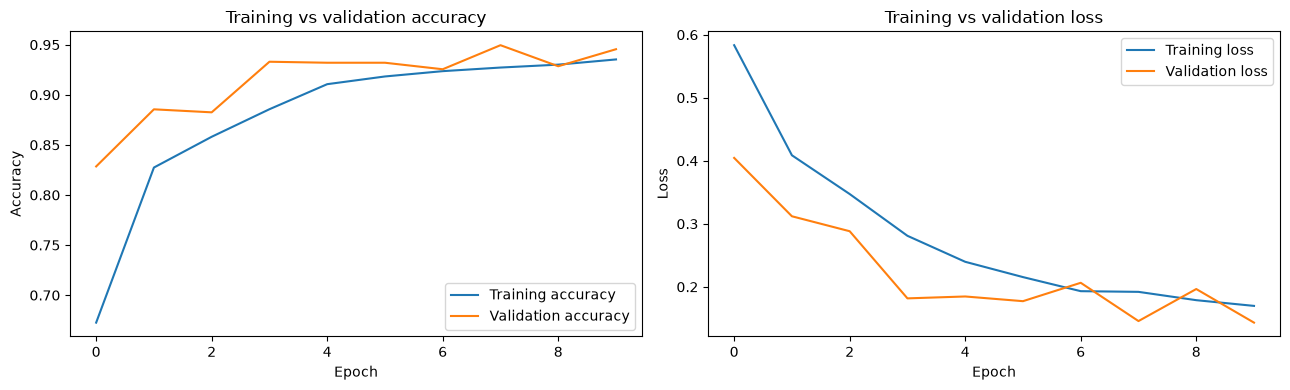

In [13]:
history_data = history.history
figure, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history_data['accuracy'], label='Training accuracy')
axes[0].plot(history_data['val_accuracy'], label='Validation accuracy')
axes[0].set(title='Training vs validation accuracy', xlabel='Epoch', ylabel='Accuracy')
axes[0].legend()
axes[1].plot(history_data['loss'], label='Training loss')
axes[1].plot(history_data['val_loss'], label='Validation loss')
axes[1].set(title='Training vs validation loss', xlabel='Epoch', ylabel='Loss')
axes[1].legend()
plt.tight_layout()
plt.show()

## 12. Evaluate the Model

Accuracy is useful, but the classification report and confusion matrix show errors for each dataset label and how the two classes were confused.

Validation images used: 2,000
Validation Accuracy: 94.55%
              precision    recall  f1-score   support

      female       0.95      0.94      0.95      1000
        male       0.94      0.95      0.95      1000

    accuracy                           0.95      2000
   macro avg       0.95      0.95      0.95      2000
weighted avg       0.95      0.95      0.95      2000



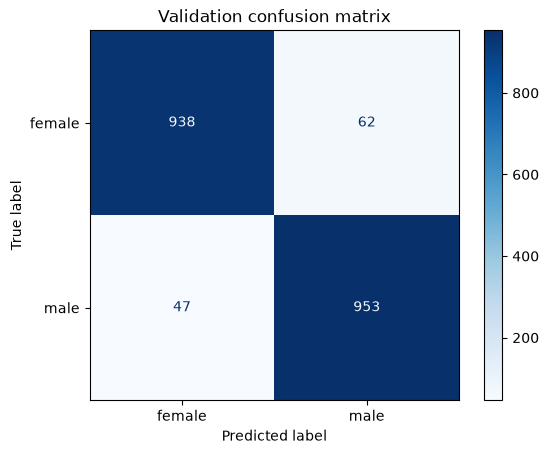

In [14]:
loss, accuracy = model.evaluate(validation_dataset, verbose=0)
print(f'Validation images used: {len(validation_labels):,}')
print(f'Validation Accuracy: {accuracy * 100:.2f}%')

y_probabilities = model.predict(validation_images, batch_size=BATCH_SIZE, verbose=0).ravel()
y_predictions = (y_probabilities >= 0.5).astype(int)
print(classification_report(validation_labels, y_predictions, target_names=class_names, zero_division=0))

matrix = confusion_matrix(validation_labels, y_predictions)
ConfusionMatrixDisplay(matrix, display_labels=class_names).plot(cmap='Blues')
plt.title('Validation confusion matrix')
plt.show()

## 13. Save the Model

The Keras model is saved in the project `models/` folder and can be loaded later without training again.

In [15]:
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
model.save(MODEL_PATH)
print(f'Saved model to: {MODEL_PATH}')

Saved model to: /workspaces/ImageClassficiationProject/models/gender_cnn.keras


## 14. Single Image Prediction

The steps are: read image, detect face, crop face, resize to `128 x 128`, and let the CNN classify the RGB crop. A probability is a model score, not a guarantee.

In [4]:
face_detector = cv2.FaceDetectorYN.create(
    str(FACE_DETECTOR_PATH), '', (320, 320), FACE_SCORE_THRESHOLD, 0.3, 5000
)


def load_model(model_path=MODEL_PATH):
    model_path = Path(model_path)
    if not model_path.is_file():
        print(f'Model file not found: {model_path}')
        print('Run the training and save sections first.')
        return None
    return tf.keras.models.load_model(model_path)


def predict_faces_on_frame(frame, trained_model):
    if frame is None or trained_model is None:
        return frame, []
    annotated = frame.copy()
    frame_height, frame_width = frame.shape[:2]
    face_detector.setInputSize((frame_width, frame_height))
    _, detections = face_detector.detect(frame)
    detections = [] if detections is None else [
        detection for detection in detections if detection[14] >= FACE_SCORE_THRESHOLD
    ]
    results = []
    face_crops = []
    face_boxes = []
    for detection in detections:
        x, y, width, height = detection[:4].astype(int)
        x, y = max(0, x), max(0, y)
        width = min(width, frame_width - x)
        height = min(height, frame_height - y)
        if width <= 0 or height <= 0:
            continue
        face = frame[y:y + height, x:x + width]
        face_rgb = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
        face_crops.append(cv2.resize(face_rgb, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA))
        face_boxes.append((x, y, width, height))
    if not face_crops:
        return annotated, results
    probabilities = trained_model.predict(np.asarray(face_crops), verbose=0).ravel()
    for (x, y, width, height), probability in zip(face_boxes, probabilities):
        label_index = 1 if probability >= 0.5 else 0
        label = class_names[label_index]
        confidence = probability if label_index == 1 else 1.0 - probability
        text = f'{label}: {confidence * 100:.1f}%'
        cv2.rectangle(annotated, (x, y), (x + width, y + height), (0, 200, 100), 2)
        cv2.putText(annotated, text, (x, max(25, y - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0, 200, 100), 2)
        results.append({'box': (x, y, width, height), 'label': label, 'confidence': float(confidence)})
    return annotated, results


def predict_image(image_path, trained_model=None):
    image_path = Path(image_path)
    if not image_path.is_file():
        print(f'Input image not found: {image_path}')
        return None
    image = cv2.imread(str(image_path))
    if image is None:
        print(f'Could not read image: {image_path}')
        return None
    trained_model = trained_model or load_model()
    annotated, results = predict_faces_on_frame(image, trained_model)
    if not results:
        print('No face detected')
    else:
        for result in results:
            print(f"Label: {result['label']} | Model score: {result['confidence'] * 100:.1f}%")
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()
    return annotated

# Uncomment after adding an image to sample_images/.
# predict_image(IMAGE_PATH, model)

## 15. Webcam Prediction

The webcam is the live demonstration. The model is loaded once, then each camera frame is detected and annotated; the CNN is not retrained for every frame.

## 16. Run the Webcam

Run `run_webcam(model)` after training and saving the model. Press `q` or `ESC` in the camera window to stop.

In [ ]:
def run_webcam(trained_model=None, camera_index=0):
    trained_model = trained_model or load_model()
    if trained_model is None:
        return
    capture = cv2.VideoCapture(camera_index)
    if not capture.isOpened():
        print(f'Could not open webcam at index {camera_index}.')
        print('Make sure the camera is connected and available to the Python environment.')
        return
    print("Webcam started. Press 'q' or ESC to quit.")
    try:
        while True:
            success, frame = capture.read()
            if not success:
                print('Could not read a webcam frame.')
                break
            annotated, results = predict_faces_on_frame(frame, trained_model)
            if not results:
                cv2.putText(annotated, 'No face detected', (20, 35), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
            cv2.imshow('Dataset-label classification - press q to quit', annotated)
            key = cv2.waitKey(1) & 0xFF
            if key in (ord('q'), 27):
                break
    finally:
        capture.release()
        cv2.destroyAllWindows()

# Run after training and saving the model:
# run_webcam(model)

: 